In [3]:
import numpy as np
import pandas as pd
import soundfile as sf
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [4]:
BASE_DIR = Path("aug_data/train_data")

In [5]:
FILENAME_PATTERN = re.compile(
    r"(class[01])_([a-zA-Z0-9]+)_(\d+)_(noise|fast|slow|chop)_(\d+)\.npy$"
)

def extract_aug_metadata(filepath: Path):
    match = FILENAME_PATTERN.match(filepath.name)
    if not match:
        # print("skipped: ",str(filepath.name)," (invalid filename format)")
        return None

    class_name, speaker, recording_id, aug_type, segment_id = match.groups()
    
    try:
        mel = np.load(filepath)
    except Exception as e:
        print("load error:", filepath.name, e)
        return None

    if mel.ndim != 2:
        print("invalid mel shape:", filepath.name)
        return None

    return {
        "path": str(filepath),
        "dataset_split": filepath.parts[-2],
        "class_number": int(class_name[-1]),
        "class_name": class_name,
        "speaker": speaker,
        "recording_id": int(recording_id),
        "segment_id": int(segment_id),
        "augmentation": aug_type,
        "n_mels": mel.shape[0],
        "n_frames": mel.shape[1],
        "mean": float(np.mean(mel)),
        "std": float(np.std(mel)),
    }

In [6]:
rows = []
for f in BASE_DIR.rglob("*.npy"):
    meta = extract_aug_metadata(f)
    if meta:
        rows.append(meta)

df_aug = pd.DataFrame(rows)
print("Loaded augmented files:", df_aug.shape)

Loaded augmented files: (15374, 12)


After applying data augmentation, the resulting audio recordings were converted into mel-spectrograms and analyzed to verify dataset consistency and quality. In total, 15,374 augmented spectrograms were generated. No duplicate samples were detected when considering speaker identity, recording ID, segment ID, and augmentation type, confirming that each augmented instance is unique.

In [7]:
print("Number of duplicates:",df_aug.duplicated(
    subset=["speaker", "recording_id", "segment_id", "augmentation"]).sum())

print("\nUnique spectrogram shapes:")
print(df_aug[["n_mels", "n_frames"]].drop_duplicates())

Number of duplicates: 0

Unique spectrogram shapes:
   n_mels  n_frames
0      80       300


All augmented spectrograms share a fixed dimensionality of 80 mel bins and 300 time frames, ensuring uniform input size for model training.


Augmentation count per class:
augmentation  chop  fast  noise  slow
class_name                           
class0        2049  1627   2046  2473
class1        1783  1426   1828  2142
ALL           3832  3053   3874  4615


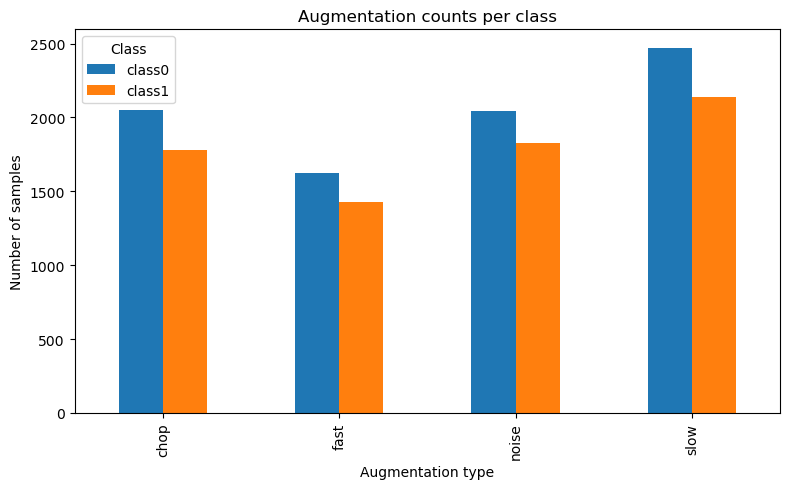

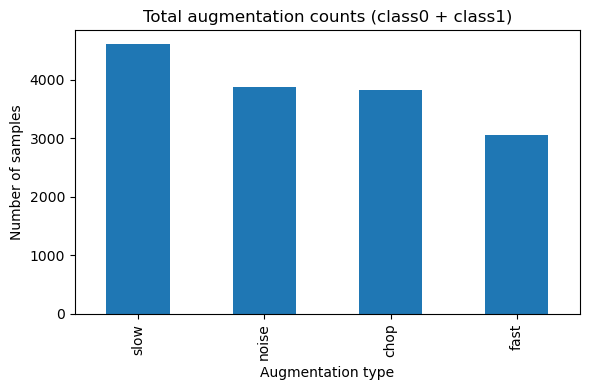

In [8]:
print("\nAugmentation count per class:")
ct = pd.crosstab(df_aug["class_name"], df_aug["augmentation"])
ct.loc["ALL"] = ct.sum()
print(ct)

ct = pd.crosstab(df_aug["augmentation"], df_aug["class_name"])

ct.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Augmentation counts per class")
plt.xlabel("Augmentation type")
plt.ylabel("Number of samples")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

aug_sum = df_aug["augmentation"].value_counts()

plt.figure(figsize=(6, 4))
aug_sum.plot(kind="bar")

plt.title("Total augmentation counts (class0 + class1)")
plt.xlabel("Augmentation type")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()


The distribution of samples across augmentation types is not uniform. Slow time-stretching produces the highest number of spectrograms, while fast time-stretching produces fewer samples. This behavior results naturally from the duration changes introduced by time-stretching and does not introduce class imbalance, as both classes are affected proportionally.

In [9]:
summary = df_aug.groupby(["class_name", "augmentation"])[["mean", "std"]].mean().round(4)
print(summary)

                           mean     std
class_name augmentation                
class0     chop         -0.0000  1.0002
           fast         -0.0001  1.0003
           noise         0.0005  0.9999
           slow         -0.0001  1.0003
class1     chop         -0.0000  1.0003
           fast         -0.0001  1.0002
           noise         0.0004  0.9999
           slow         -0.0001  1.0003


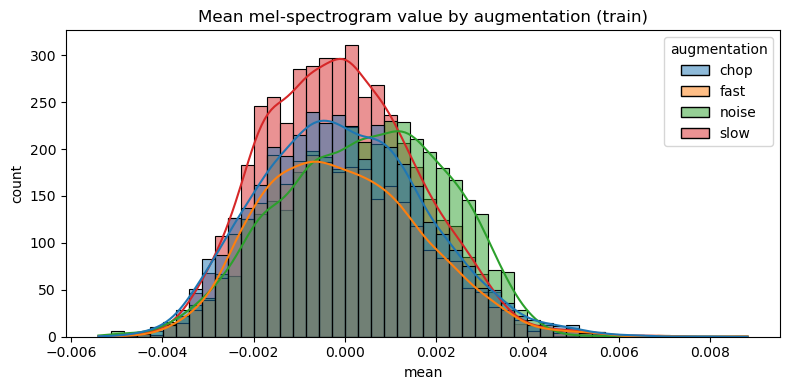

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_aug,
    x="mean",
    hue="augmentation",
    bins=50,
    kde=True
)
plt.title("Mean mel-spectrogram value by augmentation (train)")
plt.xlabel("mean")
plt.ylabel("count")
plt.tight_layout()
plt.show()

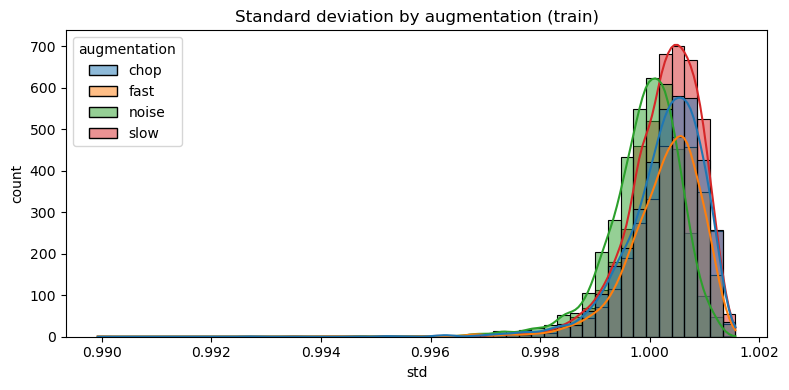

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_aug,
    x="std",
    hue="augmentation",
    bins=50,
    kde=True
)
plt.title("Standard deviation by augmentation (train)")
plt.xlabel("std")
plt.ylabel("count")
plt.tight_layout()
plt.show()

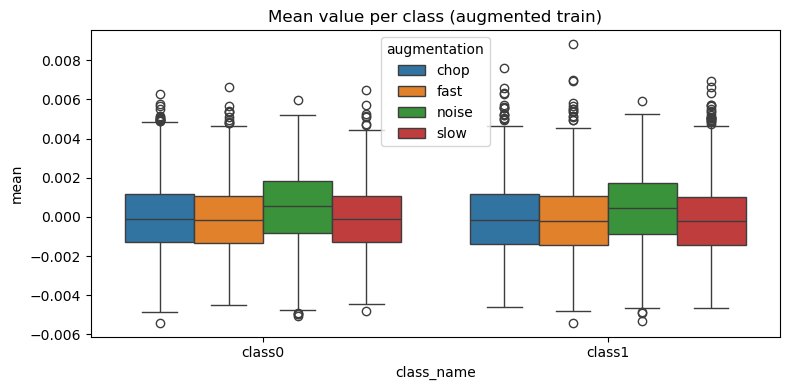

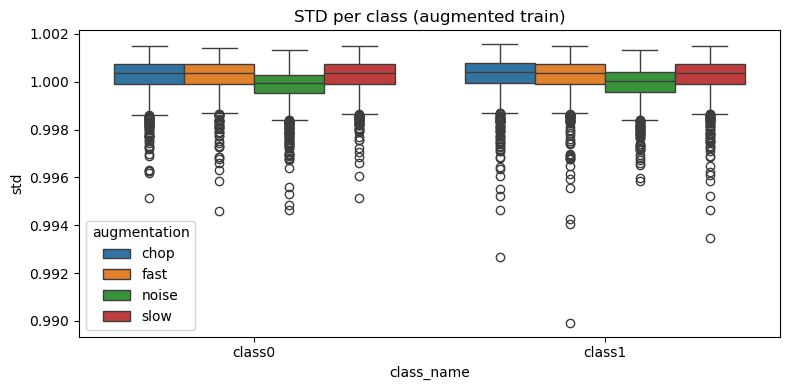

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_aug, x="class_name", y="mean", hue="augmentation")
plt.title("Mean value per class (augmented train)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_aug, x="class_name", y="std", hue="augmentation")
plt.title("STD per class (augmented train)")
plt.tight_layout()
plt.show()

Statistical analysis shows that the mean values of the augmented mel-spectrograms are all very close to zero, and the standard deviations are approximately one, indicating that the augmentations do not introduce any significant bias or scaling changes. This suggests that each augmentation type preserves the overall energy distribution of the original audio, ensuring that the dataset remains consistent for training.

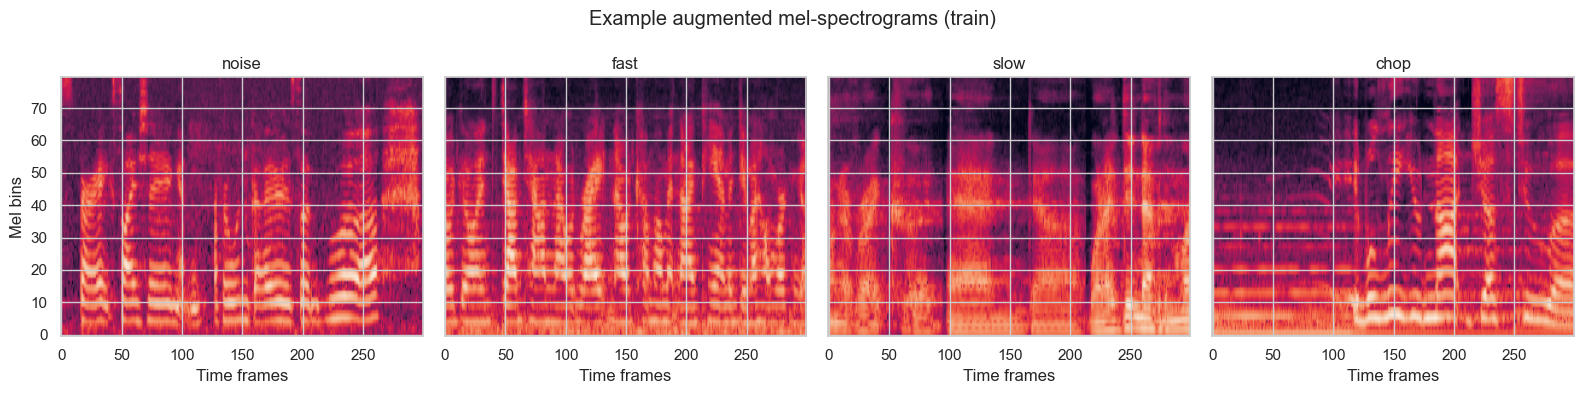

In [13]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, aug in zip(axes, ["noise", "fast", "slow", "chop"]):
    sample = df_aug[df_aug["augmentation"] == aug].sample(1)
    mel = np.load(sample["path"].iloc[0])
    ax.imshow(mel, aspect="auto", origin="lower")
    ax.set_title(aug)
    ax.set_xlabel("Time frames")

axes[0].set_ylabel("Mel bins")
plt.suptitle("Example augmented mel-spectrograms (train)")
plt.tight_layout()
plt.show()

Visual inspection of example spectrograms confirms that each augmentation modifies the temporal structure as intended while preserving characteristic spectral patterns. Overall, the augmented spectrograms remain consistent and suitable for training, supporting robust feature learning without distorting speaker-specific information.